In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
#2) Load Dataset

df = pd.read_excel("ABC Company.xlsx")

print("Shape:", df.shape)   # expected (458, 9)
print(df.head())
print(df.columns)

Shape: (458, 9)
            Name            Team  Number Position  Age               Height  \
0  Avery Bradley  Boston Celtics       0       PG   25  2023-02-06 00:00:00   
1    Jae Crowder  Boston Celtics      99       SF   25  2023-06-06 00:00:00   
2   John Holland  Boston Celtics      30       SG   27  2023-05-06 00:00:00   
3    R.J. Hunter  Boston Celtics      28       SG   22  2023-05-06 00:00:00   
4  Jonas Jerebko  Boston Celtics       8       PF   29  2023-10-06 00:00:00   

   Weight            College     Salary  
0     180              Texas  7730337.0  
1     235          Marquette  6796117.0  
2     205  Boston University        NaN  
3     185      Georgia State  1148640.0  
4     231                NaN  5000000.0  
Index(['Name', 'Team', 'Number', 'Position', 'Age', 'Height', 'Weight',
       'College', 'Salary'],
      dtype='object')


In [4]:
# 3) Preprocessing
# Replace height with random values 150 to 180


np.random.seed(42)
df["height"] = np.random.randint(150, 181, size=len(df))  # 150 to 180 inclusive

print(df["height"].head())
print(df["height"].describe())

0    156
1    169
2    178
3    164
4    160
Name: height, dtype: int64
count    458.000000
mean     165.085153
std        9.412232
min      150.000000
25%      156.250000
50%      165.000000
75%      174.000000
max      180.000000
Name: height, dtype: float64


In [6]:
# 4) Task 1: Team Distribution + Percentage

Team_count = df["Team"].value_counts()
Team_percent = (df["Team"].value_counts(normalize=True) * 100).round(2)

Team_summary = pd.DataFrame({
    "Employee Count": Team_count,
    "Percentage (%)": Team_percent
})
print(Team_summary)

                        Employee Count  Percentage (%)
Team                                                  
New Orleans Pelicans                19            4.15
Memphis Grizzlies                   18            3.93
Utah Jazz                           16            3.49
Milwaukee Bucks                     16            3.49
New York Knicks                     16            3.49
Boston Celtics                      15            3.28
Los Angeles Clippers                15            3.28
Los Angeles Lakers                  15            3.28
Phoenix Suns                        15            3.28
Sacramento Kings                    15            3.28
Brooklyn Nets                       15            3.28
Philadelphia 76ers                  15            3.28
Toronto Raptors                     15            3.28
Golden State Warriors               15            3.28
Indiana Pacers                      15            3.28
Detroit Pistons                     15            3.28
Cleveland 

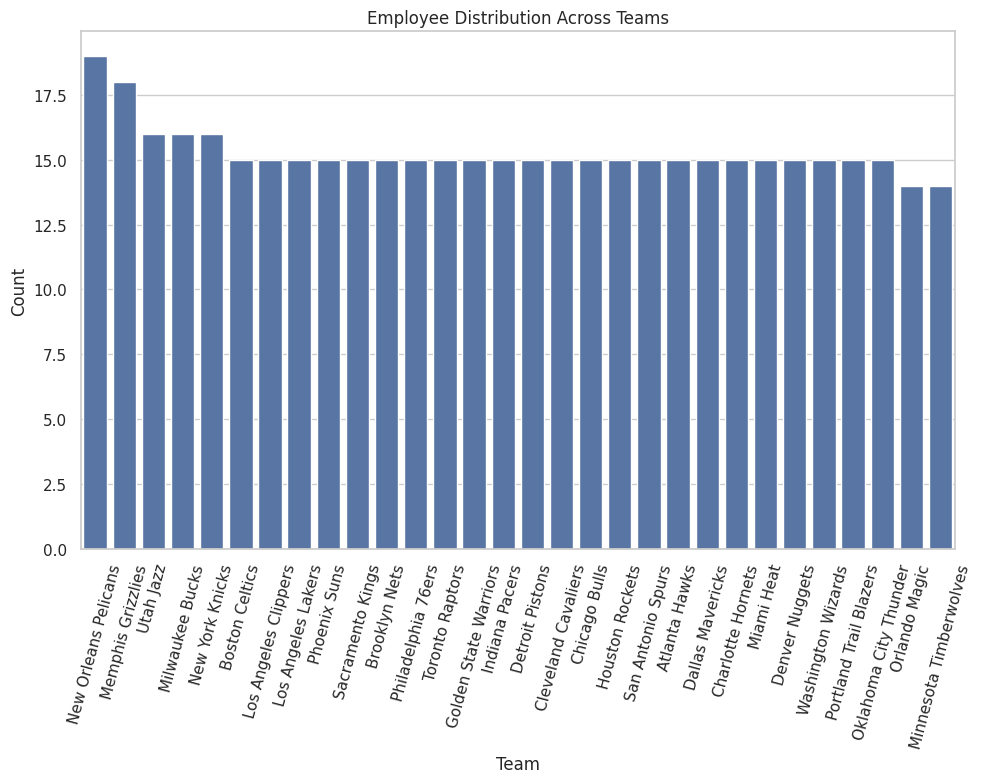

In [13]:
plt.figure(figsize=(10,8))
sns.countplot(data=df, x="Team", order=df["Team"].value_counts().index)
plt.title("Employee Distribution Across Teams")
plt.xlabel("Team")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [15]:

position_count = df["Position"].value_counts()
print(position_count)

Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64


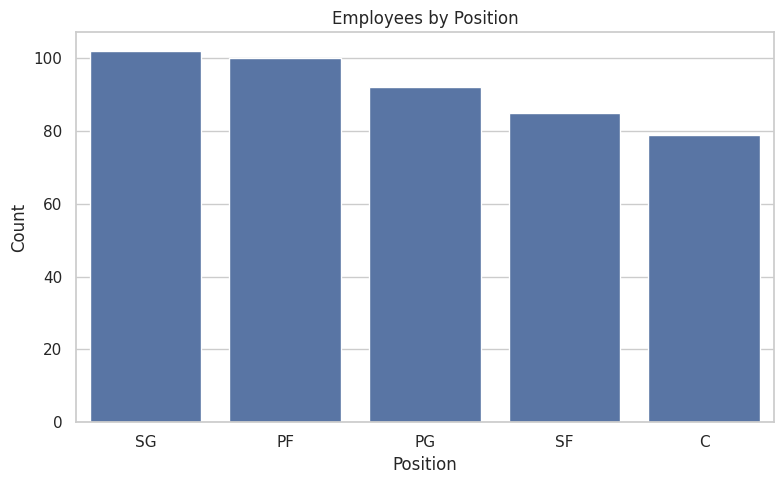

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Position", order=df["Position"].value_counts().index)
plt.title("Employees by Position")
plt.xlabel("Position")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


Age Group Distribution:
 AgeGroup
18-25    200
26-30    167
31-35     68
36-40     23
41-45      0
46-50      0
Name: count, dtype: int64
Predominant Age Group: 18-25


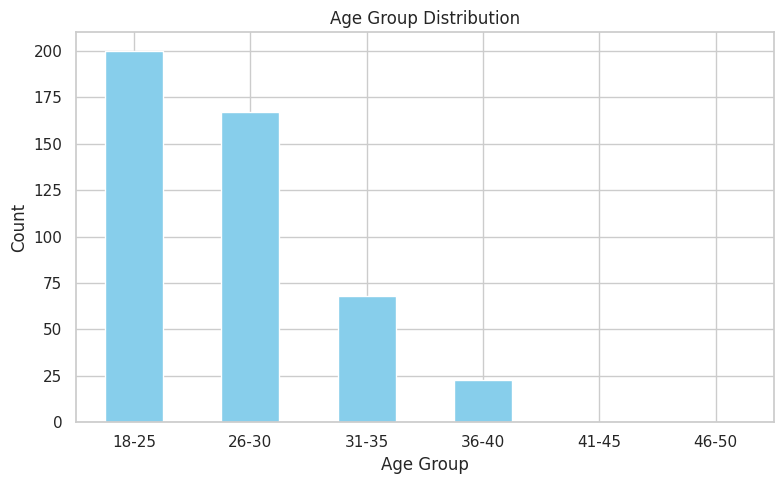

In [20]:
# 4) Predominant Age Group

bins = [18, 25, 30, 35, 40, 45, 50]
labels = ["18-25", "26-30", "31-35", "36-40", "41-45", "46-50"]

df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels, include_lowest=True)
age_group_count = df["AgeGroup"].value_counts().sort_index()

print("\nAge Group Distribution:\n", age_group_count)
print("Predominant Age Group:", age_group_count.idxmax())

plt.figure(figsize=(8, 5))
age_group_count.plot(kind="bar", color="skyblue")
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
# 5) Highest Salary Expenditure

team_salary = df.groupby("Team")["Salary"].sum().sort_values(ascending=False)
position_salary = df.groupby("Position")["Salary"].sum().sort_values(ascending=False)

print("\nHighest Salary Team:", team_salary.idxmax(), "->", team_salary.max())
print("Highest Salary Position:", position_salary.idxmax(), "->", position_salary.max())






Highest Salary Team: Cleveland Cavaliers -> 106988689.0
Highest Salary Position: C -> 466377332.0


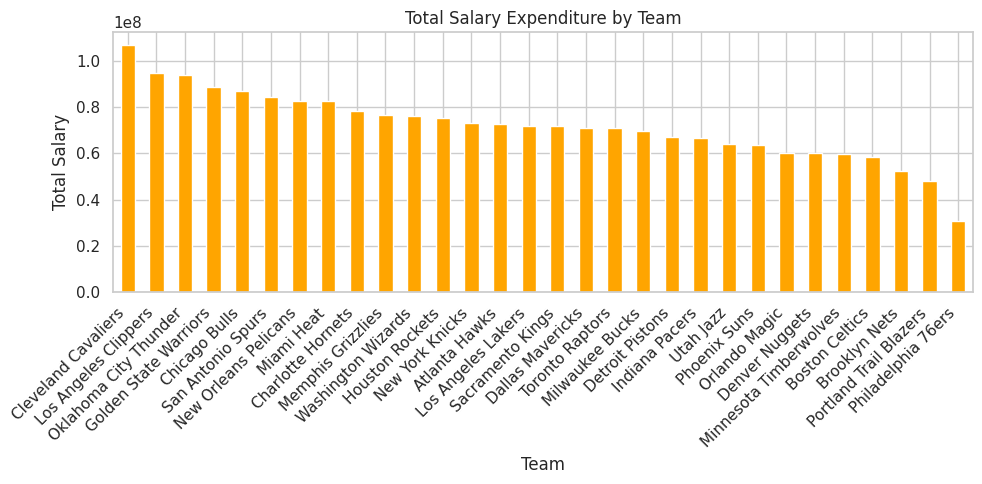

In [22]:
plt.figure(figsize=(10, 5))
team_salary.plot(kind="bar", color="orange")
plt.title("Total Salary Expenditure by Team")
plt.xlabel("Team")
plt.ylabel("Total Salary")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


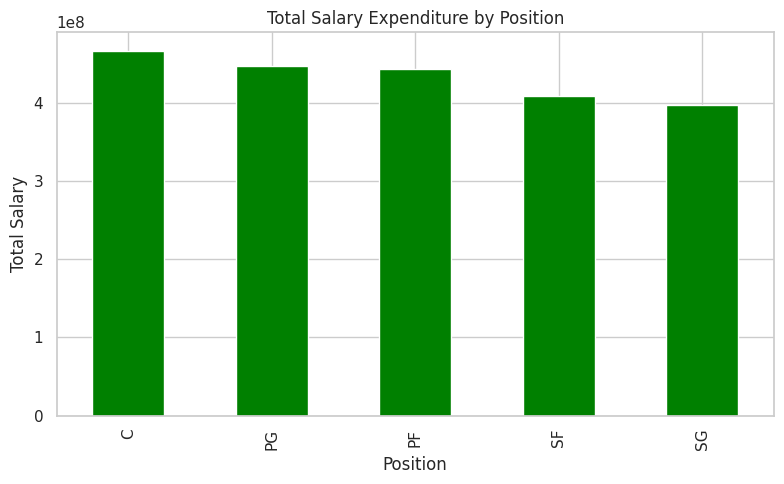

In [24]:
plt.figure(figsize=(8, 5))
position_salary.plot(kind="bar", color="green")
plt.title("Total Salary Expenditure by Position")
plt.xlabel("Position")
plt.ylabel("Total Salary")
plt.tight_layout()
plt.show()


Correlation (Age vs Salary): 0.214


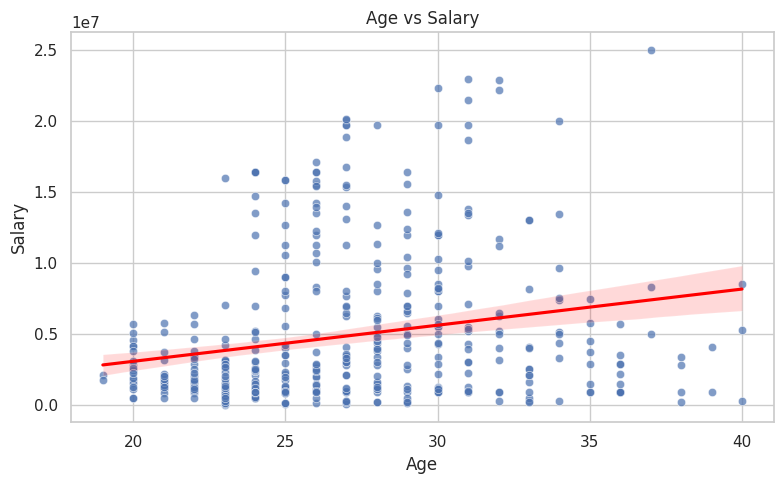

In [25]:
#6) Correlation between Age and Salary

corr_value = df["Age"].corr(df["Salary"])
print("\nCorrelation (Age vs Salary):", round(corr_value, 4))

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Age", y="Salary", alpha=0.7)
sns.regplot(data=df, x="Age", y="Salary", scatter=False, color="red")
plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.tight_layout()
plt.show()

In [26]:
# Save cleaned data
df.to_csv("ABC_company_cleaned.csv", index=False)
print("\nSaved file: ABC_company_cleaned.csv")



Saved file: ABC_company_cleaned.csv
